In [51]:
import os

os.environ.pop("CURL_CA_BUNDLE", None)

print("CURL_CA_BUNDLE =", os.environ.get("CURL_CA_BUNDLE"))

CURL_CA_BUNDLE = None


In [52]:
from langchain_google_genai import ChatGoogleGenerativeAI
from IPython.display import display, Image
import wikipedia
from langchain_community.tools import WikipediaQueryRun, DuckDuckGoSearchResults
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import ToolMessage, HumanMessage

from dotenv import load_dotenv
import os
load_dotenv()


if os.environ['GEMINI_API_KEY']:
    print('gemini key set')
else:
    print("not set")

gemini key set


# **Initialize LLM**

In [53]:
# Initialize the Gemini model
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.7,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)


In [54]:

@tool
def duck_tool(query: str):
    """"This tool allows you to search duck duck go for information on a given topic"""
    tool = DuckDuckGoSearchResults()

    return tool.invoke(query)
    
    
# result = duck_tool.invoke({"query": "what are the Trending news in kenya about Linda Mwananchi"})
# print(result)

result = duck_tool.invoke({"query": "What is LangChain?"})
print(result)

snippet: LangChain is an open-source framework that simplifies building applications using large language models. It helps developers connect LLMs with external data, tools and workflows and is available in both Python and JavaScript., title: Introduction to LangChain - GeeksforGeeks, link: https://www.geeksforgeeks.org/artificial-intelligence/introduction-to-langchain/, snippet: LangChain is a framework that simplifies the process of building applications using Large Language Models (LLMs). It provides a set of modular building blocks that developers can use to design, integrate and deploy intelligent systems., title: The Complete LangChain Ecosystem - GeeksforGeeks, link: https://www.geeksforgeeks.org/artificial-intelligence/the-complete-langchain-ecosystem/, snippet: LangChain is available in the Python and JavaScript libraries and can aid in the development of applications such as chatbots and virtual agents. What is the LangChain framework? LangChain's framework includes various c

## **Arxiv Retriever**

In [55]:
# from langchain_community.retrievers import ArxivRetriever
# from langchain_community.tools import ArxivQueryRun
# from langchain_community.utilities import ArxivAPIWrapper

# arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

# arxiv_query.invoke("Transformers in NLP")

# # retriever = ArxivRetriever( load_max_docs=2, get_ful_documents=True, )

# # docs = retriever.invoke("Transformers in NLP")


# **Wikipedia Search Tool**

In [56]:


wikipedia.set_user_agent(
    "LangGraphTutorial/1.0 (educational project)"
)

@tool
def wiki_tool(query: str):
    """"This tool allows you to search wikipedia for information on a given topic"""
    wiki = WikipediaAPIWrapper()

    wiki_query = WikipediaQueryRun(api_wrapper=wiki)

    result = wiki_query.invoke(query)
    # print(result)
    return result

result = wiki_tool.invoke({"query": "What is LangChain?"})
print(result)

Page: List of artificial intelligence companies
Summary: Below is a list of notable companies that primarily focus on artificial intelligence (AI). Companies that simply make use of AI but have a different primary focus are not included.

Page: Agent harness
Summary: An agent harness is the software infrastructure surrounding a large language model (LLM) that enables it to operate as an AI agent: it manages tool use, memory, state persistence, execution environments and feedback loops, as opposed to the model's own reasoning. A shorthand popularised in 2026 expresses the relationship as Agent = Model + Harness.
Because an LLM is stateless and, unaided, produces only text, the harness is what allows a model to take actions over multiple steps, use external tools, and sustain a long-running task across sessions. Rather than repeatedly re-reading an ever-growing transcript inside the context window, a harness can offload record-keeping into a structured software environment that manages t

## **Custom Tool**

In [57]:


@tool
def personal_info(name: str):
    """
    use this tool to get personal information about Alice, Bob and Charlie.
    """
    
    info = {
        "Alice":"Alice is a software engineer with 5 years experience in AI",
        "Bob":"Bob is a data scientist. Loves working with large datasets",
        "Charlie":"Charlie is a product manager with a background in tech startups"
    }
    
    return info.get(name, "no information available for this person")

personal_info.invoke("Alice")

'Alice is a software engineer with 5 years experience in AI'

## **Tool Binding**

In [58]:
tools = [duck_tool, wiki_tool, personal_info]

llm_with_tools = llm.bind_tools(tools)

response = llm_with_tools.invoke("What is LangChain?")

response.tool_calls

[{'name': 'duck_tool',
  'args': {'query': 'what is LangChain'},
  'id': 'call_390523',
  'type': 'tool_call'}]

# **LangGraph Creation**

### **Create Schema**

In [59]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages: List

### **Create Node Functions**

In [60]:
def llm_node(state:graph_schema)->graph_schema:
    messages = state['messages']
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","You are a helpful assistant that can use tools to answer questions"),
            ("human","{input}")
        ]
    )
    
    
    # llm with tools
    chain = prompt | llm_with_tools
    
    response = chain.invoke({"input":messages})
    
    state['messages'] = messages + [response]
    
    
    return state

In [61]:
# from langgraph.prebuilt import ToolNode
def tool_node(state:graph_schema) -> graph_schema:
    messages = state['messages']
    
    tools_by_name = {tool.name: tool for tool in tools}
    
    tool_results = []
    
    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_results.append(ToolMessage(content=observation,tool_call_id=tool_call['id']))
        
    
    state['messages'] = messages + tool_results

### **Create Conditional Edge Function**

In [62]:
def if_tool_call(state: graph_schema) -> str:
    last_message = state['messages'][-1]
    
    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

### ***Create State Graph***

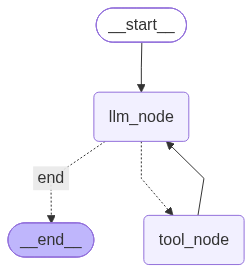

In [63]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node('llm_node', llm_node)
graph.add_node('tool_node', tool_node)


graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node":"tool_node","end":END})
graph.add_edge("tool_node","llm_node")
graph.add_edge("llm_node",END)

react_graph = graph.compile()

Image(react_graph.get_graph().draw_mermaid_png())

In [64]:
react_graph.invoke({"messages":[HumanMessage(content="What is langchain")]})

{'messages': [HumanMessage(content='What is langchain', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duck_tool', 'arguments': '{"query": "what is langchain"}'}, '__gemini_function_call_thought_signatures__': {'call_583414': 'EnEKbwERTTIPIgnZVg1LiIqIZLqNQxA19jCnwVs12aCVYQ2ymOYeKxORI5F1Vtf7KxcF6WSVWb8FxoKC/wXQG+01OeOS5+mmoPLWkzvyHnO2GtvvrcD+nmKdhLVZ1fJQFgGfABe4HiuxEclOWCrKBSBvZQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a024bb-a983-7ce1-a688-bd5c3601d507-0', tool_calls=[{'name': 'duck_tool', 'args': {'query': 'what is langchain'}, 'id': 'call_583414', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 187, 'output_tokens': 18, 'total_tokens': 205, 'input_token_details': {'cache_read': 0}}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duck_tool', 'argu

In [65]:
for chunk in react_graph.stream(
    {"messages":[HumanMessage(content="What is langchain")]},
    stream_mode="updates"
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='What is langchain', additional_kwargs={}, response_metadata={}), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duck_tool', 'arguments': '{"query": "what is langchain"}'}, '__gemini_function_call_thought_signatures__': {'call_332214': 'EnEKbwERTTIPDTTyAR9GliSt49XQRPlt5wnHru9ZMJvt6PDibXsYbseqxwZbLNgX7BPR5zNFDNGYoORF2j/NvktphKgPn6IvFnSMnHguO8yBPw/Gc7IBg+f7OT7vVDbYq2R+6pANPmoWxjcUp5IFRef5RQ=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a024be-7739-75b1-af7c-69db0536a052-0', tool_calls=[{'name': 'duck_tool', 'args': {'query': 'what is langchain'}, 'id': 'call_332214', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 187, 'output_tokens': 18, 'total_tokens': 205, 'input_token_details': {'cache_read': 0}})]}}
{'tool_node': None}
{'llm_node': {'messages': [HumanMessage(content='What 

KeyboardInterrupt: 